In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

In [26]:
DATASET_PATH = "./data"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

In [28]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("Classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Found 7863 files belonging to 5 classes.
Using 6291 files for training.
Found 7863 files belonging to 5 classes.
Using 1572 files for validation.
Classes:
0 : Cassava___bacterial_blight
1 : Cassava___brown_streak_disease
2 : Cassava___green_mottle
3 : Cassava___healthy
4 : Cassava___mosaic_disease


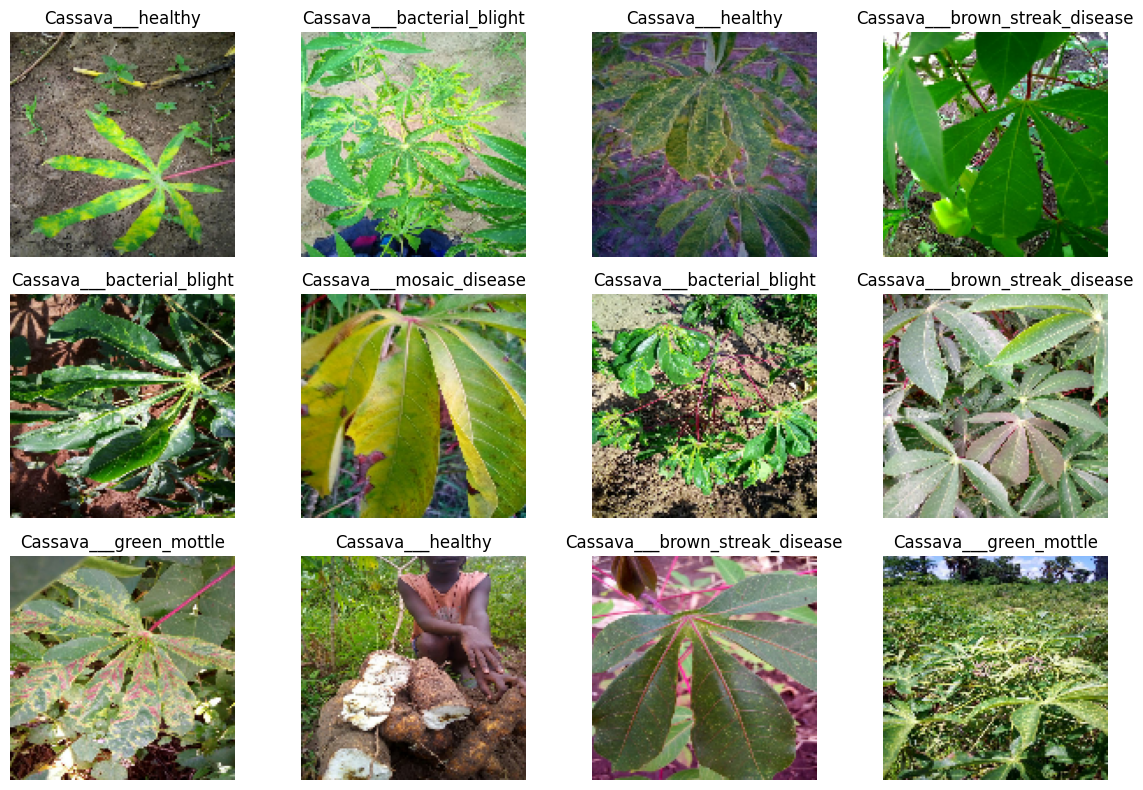

In [30]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [34]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)

In [36]:
num_classes = len(class_names)

model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixel values from [0,255] to [0,1]
    layers.Rescaling(1./255),

    # Convolution Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 4
    layers.Conv2D(
        256,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    # Output layer
    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

In [38]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,837 (5.98 MB)

 Trainable params: 1,568,837 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [42]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 93s 379ms/step - accuracy: 0.3845 - loss: 1.4692 - val_accuracy: 0.4288 - val_loss: 1.3762
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 72s 366ms/step - accuracy: 0.4330 - loss: 1.3711 - val_accuracy: 0.4434 - val_loss: 1.3189
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 74s 373ms/step - accuracy: 0.4605 - loss: 1.3125 - val_accuracy: 0.4224 - val_loss: 1.4006
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 73s 371ms/step - accuracy: 0.4704 - loss: 1.2856 - val_accuracy: 0.4631 - val_loss: 1.2571
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 75s 382ms/step - accuracy: 0.4727 - loss: 1.2716 - val_accuracy: 0.4631 - val_loss: 1.2659
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 76s 384ms/step - accuracy: 0.4769 - loss: 1.2585 - val_accuracy: 0.4809 - val_loss: 1.2455
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 77s 391ms/step - accuracy: 0.4899 - loss: 1.2301 - val_accuracy: 0.4854 - val_loss: 1.1983
Epoch 8/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 75s 379ms/step - accuracy: 0.5037 - loss: 1

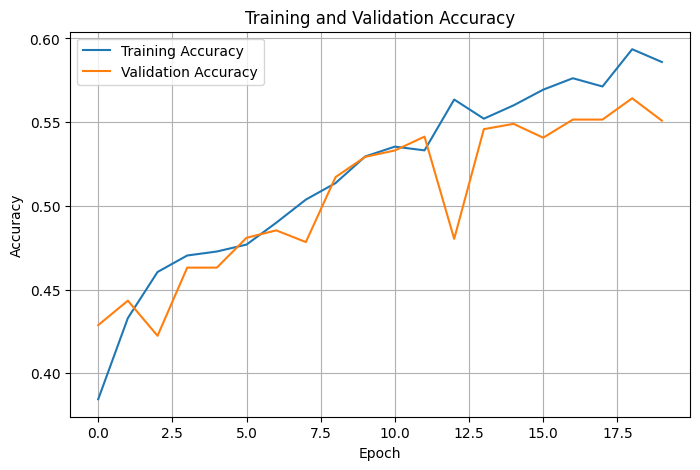

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

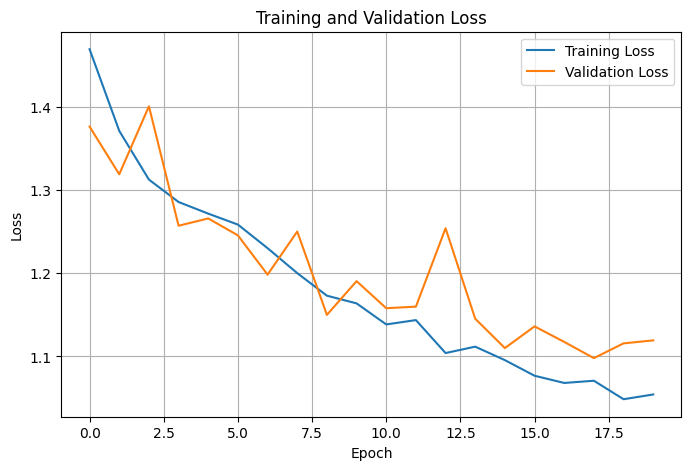

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [45]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)
print("Validation Accuracy (%):", accuracy * 100)

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.5509 - loss: 1.1193
Validation Loss: 1.1193416118621826
Validation Accuracy: 0.5508905649185181
Validation Accuracy (%): 55.08905649185181


In [46]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [47]:
cm = confusion_matrix(
    y_true,
    y_pred
)

In [48]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.56      0.94      0.70       534
Cassava___brown_streak_disease       0.33      0.01      0.02       192
        Cassava___green_mottle       0.47      0.36      0.41       313
             Cassava___healthy       0.70      0.31      0.43       306
      Cassava___mosaic_disease       0.53      0.67      0.59       227

                      accuracy                           0.55      1572
                     macro avg       0.52      0.46      0.43      1572
                  weighted avg       0.54      0.55      0.49      1572



In [70]:
from tensorflow.keras.utils import load_img, img_to_array

image_path = "test_leaf.jpeg"

img = load_img(
    image_path,
    target_size=IMG_SIZE
)

img_array = img_to_array(img)

img_array = tf.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index] * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
Predicted Disease: Cassava___green_mottle
Confidence: 49.84 %


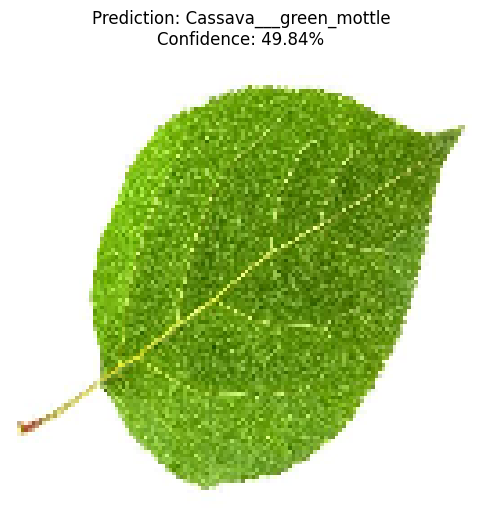

In [72]:
plt.figure(figsize=(6, 6))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()

In [68]:
model.save(
    "cassava_leaf_disease_cnn.keras"
)

print("Model saved successfully!")

Model saved successfully!
